
# Defusing sarcasm with Transformers

## Description

Goal of this project is to train LLMs based on the transformer architecture to behave as a "sarcasm defuser". The sarcasm defuser's job is to take as input a sarcastic comment and convert it into a "neutral" comment with the same meaning but stripped of all sarcastic connotation.

### Example:

 * **ORIGINAL COMMENT:** "_Because everything wrong with the community is the fault of liberals._"
 * **NEUTRAL COMMENT:** "_It seems like many problems within the community are attributed to liberals._"

The original comment decries sarcastically how many problems in the community are ascribed to liberals. The neutral comment conveys the same meaning but with a less sarcastic tone.


## Outline:

In the rest of this document, we will: 

1. Briefly introduce the transformer architecture and LLMs.
2. Describe the dataset that we use to train our LLMs to defuse sarcasm. 
3. Describe the methodology we use to quantitatively evaluate the trained model
4. Briefly describe how the models were trained and present the results. 
5. Finally, we'll outline the shortcomings of this analysis as well as possible ideas for future work

In [3]:
import pandas as pd
import numpy as np
import os
from google import genai
from tqdm import tqdm
from tenacity import retry
from tenacity.wait import wait_exponential
from tenacity.before import before_log
from tqdm.auto import tqdm
import torch
import logging
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", None)


DATA_DIR = "data/SARC"

## Transformer architecture

The Transformer architecture is the engine behind almost every modern AI you interact with today, from ChatGPT to Gemini.

It was introduced by Google researchers in the seminal 2017 paper: ["Attention is All You Need."](https://arxiv.org/abs/1706.03762) 

### Why It’s a Game-Changer
Before Transformers, AI processed text like a human reads a book: one word at a time, from left to right (using RNNs or LSTMs). This was slow and "forgot" the beginning of long sentences. Transformers changed the game for two reasons:

Parallelization: They process entire sentences all at once rather than sequentially. This makes them incredibly fast to train on massive datasets using GPUs.

Self-Attention: This mechanism allows the model to weigh the importance of every word in a sentence simultaneously. It "pays attention" to the relevant context, no matter how far apart the words are. If you're interested in the details of how the transformer's architecture works, we defer you to the original ["Attention is All You Need."](https://arxiv.org/abs/1706.03762) paper.


<img src="./media/transformers.jpeg" width="800" />

The original Transformer consists of two main parts:

1. **The Encoder:** Reads and understands the input text, turning it into a mathematical representation.

2. **The Decoder:** Uses that representation to generate an output (like a translation or a response).

Dependending on which of the 2 above components are present, a transformer could be *encoder-only*, *deceoder-only*, or *encoder-decoder*:

| Feature | **Encoder-Only** | **Decoder-Only** | **Encoder-Decoder** |
| :--- | :--- | :--- | :--- |
| **Core Strength** | Understanding & Context | Generation & Prediction | Translation & Transformation |
| **Mechanism** | Reads the whole sequence at once (Bi-directional). | Predicts the next word based on previous ones (Auto-regressive). | Maps an input sequence to a new output sequence. |
| **Common Use Case** | Sentiment analysis, NER, Classification. | Chatbots, Storytelling, Code generation. | Translation, Summarization, Speech-to-text. |
| **Popular Models** | BERT, RoBERTa, ELECTRA | **GPT-4**, Llama 3, Gemini, Claude | T5, **BART**, Original Transformer |

In this project, we're gonna work on both **GPT** (decoder-only) and **BART** (encoder-decoder) to try to turn them into effective sarcasm defusers

## Dataset

In order to train our defuser, we need examples of sarcastic comments together with their "neutral" versions.

Our sarcastic comments will come from the [Sarcasm on Reddit](https://www.kaggle.com/datasets/danofer/sarcasm/data) dataset. The dataset contains around 1M sarcastic comments from the Reddit online forum, which have been marked as sarcastic with the `\s` tag by the very authors. 

### Creating a training dataset

The sarcastic comments alone aren't enough to train our sarcasm defuser, because we also need their neutral or "defused" versions i.e. for each sarcastic comment, we would like to have a comment with the same meaning but with as much of the sarcasm removed as possible. Unfortunately, the `Sarcasm on Reddit` dataset doesn't help us here.

In order to create the neutral versions of the sarcastic comments, we resort to an LLM, namely Google's [Gemma 3](https://deepmind.google/models/gemma/gemma-3/) with 12B parameter. We chose this model because it can be queried with a decent request rate via the free plan of Google's GenAI API. The idea is to ask Gemma to create a neutral version of some of our sarcastic comments so that we have paris of sarcastic/neutral comment we can use to train our models.

After playing around with a few prompts, we identify the following to be quite effective:

```
given this sarcastic comment: <SARCASTIC_COMMENT>, which is a response to this other comment: <CONTEXT>,
remove all the sarcasm from it while keeping the original meaning. Don't output anything else, and don't try to describe the comment in the third person
```

here, `<SARCASTIC_COMMENT>` is the original sarcastic comment we want Gemma to neutralize while `<CONTEXT>` is the comment that was preceding the sarcastic comment in the Reddit thread. This comment is available from the Kaggle dataset and we believe it gives Gemma additional information to do a better job as neutralizing the sarcastic comment while keeping the same meaning. We sample a bit less than 5000 comments from the dataset and query Gemma via the API using the prompt to obtain the neutralized versions. Here's a couple of examples:


| orignal sarcastic comment                                                                        | neutral comment generated by Gemma                                                                                        |
|:-------------------------------------------------------------------------------|:-------------------------------------------------------------------------------------------------------|
| B/c the DC narrative reflects the ideals of the majority of Americans amirite? | Considering the DC narrative doesn't necessarily align with the views of most Americans, do you agree? |
| He meant "tossback" since he can't throw far enough,                           | He meant "throwback" because he doesn't throw very far.                                                |
| Rich Piana's Real Food helped me to get bigger by the day                      | Rich Piana's Real Food helped me gain size.                                                            |


Of this ~5000 comments, we sample 90% to be our train set and 10% to be our test set, resulting in a training and test set of 4448 and 495 comments, respectively

In [100]:
sarc = pd.read_csv(f"{DATA_DIR}/train-balanced-sarcasm.csv", parse_dates=["date"])
sarc = sarc.dropna()

sarcastic = sarc[sarc.label == 1].sample(20000)

In [ ]:
gen_client = genai.Client()
model = "gemma-3-12b-it"


@retry(wait=wait_exponential(min=2, max=300))
def defuse_sarcasm(row: pd.Series, client, model):
    comment, context = row.comment, row.parent_comment
    try:
        response = client.models.generate_content(
            model=model,
            contents=[
                "given this sarcastic comment:",
                comment,
                "which is a response to this other comment:",
                context,
                "remove all the sarcasm from it while keeping the original meaning. Don't output anything else, and don't try to describe the comment in the third person",
            ],
        )
        return response.text
    except Exception as e:
        print("Api call failed: ", e)
        raise


sarc_with_neutral = f"{DATA_DIR}/sarc_with_neutral.csv"

print(f"defusing {len(sarcastic)} comments")

if os.path.isfile(sarc_with_neutral):
    checkpoint = pd.read_csv(f"{DATA_DIR}/sarc_with_neutral.csv", index_col=0)
    print(
        f"file {sarc_with_neutral} already exists, {checkpoint.shape[0]} entries already written"
    )
    sarcastic = sarcastic[~sarcastic.index.isin(checkpoint.index)]
    print(f"{len(sarcastic)} comments yet to defuse")

chunk_size = 10

chunks = [
    sarcastic[i : i + chunk_size] for i in range(0, sarcastic.shape[0], chunk_size)
]
tqdm.pandas()

for chunk in tqdm(chunks, desc="Creating neutral comment versions"):
    chunk["neutral_comment"] = chunk[["comment", "parent_comment"]].apply(
        defuse_sarcasm, args=(gen_client, model), axis=1
    )

    if not os.path.isfile(sarc_with_neutral):
        chunk.to_csv(sarc_with_neutral)
    else:
        chunk.to_csv(sarc_with_neutral, mode="a", header=False)

In [102]:
import pandas as pd

df = pd.read_csv(
    f"{DATA_DIR}/sarc_with_neutral.csv", index_col=0, parse_dates=["date"]
).dropna(subset=["comment", "neutral_comment"])

train_size = int(df.shape[0] * 0.9)

df_train = df[:train_size]
df_test = df[train_size:]


df_train.to_csv(f"{DATA_DIR}/train.csv", index=False)
df_test.to_csv(f"{DATA_DIR}/test.csv", index=False)

In [133]:
print(df.shape, df_train.shape, df_test.shape)

(4943, 11) (4448, 11) (495, 11)


# Evaluation methodology

Once we train a defuser model on the pairs of sarcastic/neutral comments, how can we assess its goodness at "defusing" sarcasm? Remember, we'd like the model to generate comments that are (1) non-sarcastic and (2) have the same meaning as the original one.

We would like therefore to assign to each comment generated by our defuser:

1. a similarity score by computing the similarity in meaning of the defused comment with the sarcastic one
2. a sarcasm score

To compute 1 and 2, we will use some sarcasm and similarity models available via [Hugging Face](https://huggingface.co/) and [Sentence Transformers](https://sbert.net/).

Here's a summary of the models we tested:

## Sarcasm models

| **Model** | Description |
|---|---|
| **[helinivan/english-sarcasm-detector](https://huggingface.co/helinivan/english-sarcasm-detector)** | English Sarcasm Detector is a text classification model built to detect sarcasm from news article titles. It is fine-tuned on bert-base-uncased |
| **[helinivan/multilingual-sarcasm-detector](https://huggingface.co/helinivan/multilingual-sarcasm-detector)** | Multilingual Sarcasm Detector is a text classification model built to detect sarcasm from news article titles. It is fine-tuned on bert-base-multilingual-uncased |
| **[pn89348/sarcasm_model](https://huggingface.co/pn89348/sarcasm_model)** | Fine-tuned version of distilbert/distilbert-base-uncased |

## Similarity models

| **Model** | Description |
|---|---|
| **[all-MiniLM-L12-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L12-v2)** | All-round model tuned for many use-cases. Trained on a large and diverse dataset of over 1 billion training pairs. |
| **[all-MiniLM-L6-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)** | All-round model tuned for many use-cases. Trained on a large and diverse dataset of over 1 billion training pairs. |
| **[all-distilroberta-v1](https://huggingface.co/sentence-transformers/all-distilroberta-v1)** | All-round model tuned for many use-cases. Trained on a large and diverse dataset of over 1 billion training pairs. |
| **[all-mpnet-base-v2](https://huggingface.co/sentence-transformers/all-mpnet-base-v2)** | All-round model tuned for many use-cases. Trained on a large and diverse dataset of over 1 billion training pairs. |
| **[multi-qa-MiniLM-L6-cos-v1](https://huggingface.co/sentence-transformers/multi-qa-MiniLM-L6-cos-v1)** | This model was tuned for semantic search: Given a query/question, it can find relevant passages. It was trained on a large and diverse set of (question, answer) pairs. |
| **[multi-qa-distilbert-cos-v1](https://huggingface.co/sentence-transformers/multi-qa-distilbert-cos-v1)** | This model was tuned for semantic search: Given a query/question, it can find relevant passages. It was trained on a large and diverse set of (question, answer) pairs. |
| **[multi-qa-mpnet-base-dot-v1](https://huggingface.co/sentence-transformers/multi-qa-mpnet-base-dot-v1)** | This model was tuned for semantic search: Given a query/question, it can find relevant passages. It was trained on a large and diverse set of (question, answer) pairs. |
| **[paraphrase-MiniLM-L3-v2](https://huggingface.co/sentence-transformers/paraphrase-MiniLM-L3-v2)** | This is a sentence-transformers model: It maps sentences & paragraphs to a 384 dimensional dense vector space and can be used for tasks like clustering or semantic search. |
| **[paraphrase-albert-small-v2](https://huggingface.co/sentence-transformers/paraphrase-albert-small-v2)** | This is a sentence-transformers model: It maps sentences & paragraphs to a 768 dimensional dense vector space and can be used for tasks like clustering or semantic search. |
| **[paraphrase-multilingual-mpnet-base-v2](https://huggingface.co/sentence-transformers/paraphrase-multilingual-mpnet-base-v2)** | This is a sentence-transformers model: It maps sentences & paragraphs to a 768 dimensional dense vector space and can be used for tasks like clustering or semantic search. |

These models can be instantiated and queried using the [Sentence Transformers](https://sbert.net/) library. They assign each pair of sentences a semantic similarity score. Different scoring metrics can be used. We choose to use [Cosine similarty](https://en.wikipedia.org/wiki/Cosine_similarity) because it's bounded in `[0, 1]` making it easier to compare across different models.

## Choosing the best similarity and sarcasm models

Out of the models listed above, we want to pick the 2 best ones (one for sarcasm, one for semantic similarity) that we will use to evaluate our trained defusing models.

In order to do so, we compute:

1. similarity between each pair of comments (original/neutral) in the training dataset
2. sarcasm score of each original comments in the training dataset
3. sarcasm score of each neutral comments in the training dataset

For all of the above, we compute median, mean, and quartiles. We also compute the ratio of the mean (median) sarcasm score of the neutral comment to the mean (median) of the sarcasm score of the original comments.

Here's the results for all models:

In [123]:
BASELINE_MODEL = "gemma-3-12b-it"


def make_bxpstats(df):
    for _, r in df.iterrows():
        iqr = r["q3"] - r["q1"]
        yield {
            "med": r["q2"],
            "q1": r["q1"],
            "q3": r["q3"],
            "whislo": r["q1"] - 1.5 * (iqr),
            "whishi": r["q3"] + 1.5 * (iqr),
            "mean": r["mean"],
        }


def make_labels(df):
    for _, r in df.iterrows():
        t = r["generate_params:temperature"]
        sample = r["generate_params:do_sample"]
        mnt = r["generate_params:max_new_tokens"]
        model = r["model"].replace("maxmarcon/", "")
        if model == BASELINE_MODEL:
            yield f"{BASELINE_MODEL} (baseline)"
        elif sample:
            yield f"{model} (temp={t}, max_new_tokens={int(mnt)})"
        else:
            yield f"{model} (greedy, max_new_tokens={int(mnt)})"

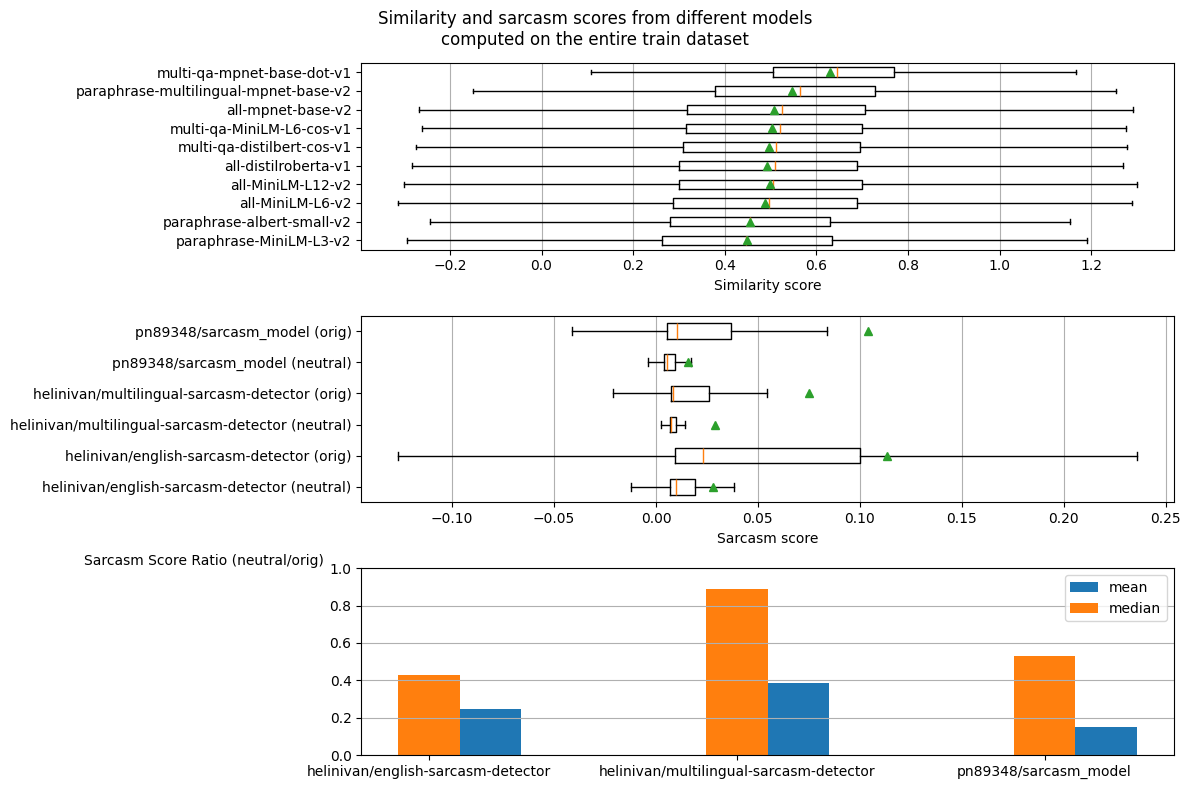

In [148]:
scoring_models = pd.read_csv("./final_project_scripts/scoring_models.csv")
scoring_models

similarity_models = scoring_models[
    [
        c
        for c in scoring_models.columns
        if c.startswith("similarity") or c == "similarity_model"
    ]
].drop_duplicates()
similarity_models.columns = [
    c.replace("similarity:", "") for c in similarity_models.columns
]
similarity_models = similarity_models.sort_values(by="q2")

sarcasm_prob = scoring_models[
    [
        c
        for c in scoring_models.columns
        if c.startswith("sarcasm") or c == "sarcasm_model"
    ]
].drop_duplicates()
sarcasm_prob_orig = sarcasm_prob[
    (
        c
        for c in sarcasm_prob.columns
        if c.startswith("sarcasm_prob_orig") or c == "sarcasm_model"
    )
]
sarcasm_prob_orig.columns = [
    c.replace("sarcasm_prob_orig:", "") for c in sarcasm_prob_orig.columns
]
sarcasm_prob_orig.loc[:, ["label"]] = sarcasm_prob_orig["sarcasm_model"] + " (orig)"

sarcasm_prob_neutral = sarcasm_prob.copy()
sarcasm_prob_neutral["median_ratio"] = (
    sarcasm_prob_neutral["sarcasm_prob_neutral:q2"]
    / sarcasm_prob_neutral["sarcasm_prob_orig:q2"]
)
sarcasm_prob_neutral["mean_ratio"] = (
    sarcasm_prob_neutral["sarcasm_prob_neutral:mean"]
    / sarcasm_prob_neutral["sarcasm_prob_orig:mean"]
)
sarcasm_prob_neutral = sarcasm_prob_neutral[
    (
        c
        for c in sarcasm_prob_neutral.columns
        if c.startswith("sarcasm_prob_neutral")
        or c in ["sarcasm_model", "mean_ratio", "median_ratio"]
    )
]
sarcasm_prob_neutral.columns = [
    c.replace("sarcasm_prob_neutral:", "") for c in sarcasm_prob_neutral.columns
]
sarcasm_prob_neutral["label"] = sarcasm_prob_neutral["sarcasm_model"] + " (neutral)"

sarcasm_stats = pd.concat([sarcasm_prob_orig, sarcasm_prob_neutral]).sort_values(
    by="label"
)

fig = plt.figure(figsize=(12, 8))
ax = plt.subplot(3, 1, 1)
fig.suptitle(
    "Similarity and sarcasm scores from different models\ncomputed on the entire train dataset"
)

similarity_models = similarity_models.sort_values(by="q2", ascending=True)
ax.bxp(
    list(make_bxpstats(similarity_models)),
    positions=range(len(similarity_models)),
    showfliers=False,
    showmeans=True,
    orientation="horizontal",
)
ax.set_xlabel("Similarity score")
ax.grid(axis="x")
ax.set_yticks(
    ticks=range(len(similarity_models)), labels=similarity_models["similarity_model"]
)
None

ax = plt.subplot(3, 1, 2)

ax.bxp(
    list(make_bxpstats(sarcasm_stats)),
    positions=range(len(sarcasm_stats)),
    showfliers=False,
    showmeans=True,
    orientation="horizontal",
)
ax.set_xlabel("Sarcasm score")
ax.grid(axis="x")
ax.set_yticks(ticks=range(len(sarcasm_stats)), labels=sarcasm_stats.label)


ax = plt.subplot(3, 1, 3)

ax.bar(
    [x + 0.2 for x in range(1, 4)],
    sarcasm_prob_neutral["mean_ratio"],
    tick_label=sarcasm_prob_neutral.sarcasm_model,
    width=0.2,
    label="mean",
)
ax.bar(
    range(1, 4),
    sarcasm_prob_neutral["median_ratio"],
    tick_label=sarcasm_prob_neutral.sarcasm_model,
    width=0.2,
    label="median",
)
ax.set_ylim(0, 1)
ax.grid(axis="y")
ax.set_ylabel("Sarcasm Score Ratio (neutral/orig)", rotation="horizontal", loc="top")
ax.legend()

fig.tight_layout()

None

The boxplots show median (red bar) 1st and 3rd quartiles (edges of the box), whiskers computed from the inter-quartile range, and the mean as a green triangle. Both similarity and sarcasm scores (for the original comments) are not as high as we had expected.

However, for the purpose of this analysis, we select `multi-qa-mpnet-base-dot-v1` as a semantic similarity model because it provides the highest similarity between comment pairs,
and we select `helinivan/english-sarcasm-detector` as the sarcasm scoring model because it provides the better separation between neutral and original comments, with the lowest ratio of median score for the neutral generated comments to the median score of the original ones.

Therefore, in all subsequent analysis, we will use these 2 models to measure semantic similarity and sarcasm, respectively. We will evaluate the goodness of our trained models based on how they perform compared to the baseline provided by `gemma-3-12b-it`. Our goal is for our models to produce neutral comments with a similarity score at least as high as the ones produced by `gemma`, and with a sarcasm score at least as low.

## Training the sarcasm defusers

We will train the following models:

| Model                                                                  | Type            | Parameters |
|------------------------------------------------------------------------|-----------------|------------|
| **[gpt2-small]( https://huggingface.co/openai-community/gpt2)**        | decoder-only    | 0.1B       |
| **[gpt2-medium](https://huggingface.co/openai-community/gpt2-medium)** | decoder-only    | 0.4B       |
| **[bart-base](https://huggingface.co/facebook/bart-base)**             | encoder-decoder | 0.1B       |

Using the Huggingface [trainer library](https://huggingface.co/docs/transformers/en/trainer). The library is built on PyTorch and provides high level tools to batch, tokenize, and train our transformer models.

These models are pretrained on a large corpus of English-language document. GPT2 is a casual model trained to predict the next work in a sentence, whereas BART is a denoising encoder-decoder (seq2seq) model trained to reconstruct the original input sentence after some of its text has been randomly corrupted.

The models process inputs by encoding them into sequences of numerical tokens, and convert the output token sequences into words. For all models, the vocabulary size (number of different tokens) is around 50257 tokens.

We will fine-tune all these models by training them on our train dataset with ~4500 sentence pairs for 10 epochs. We will feed batches of input sarcastic sentences into the models and train them to produce the "defused" neutral sentence as output. We will use cross-entropy loss as the loss function during training.

All training and evaluation was performed on machines rented via the [VastAI platform](https://vast.ai/).

However, some details of the training will be different depending on whether we're dealing with a decoder-only or with an encoder-decoder model.

### Decoder-only

Decoder-only models are causal: given an input sentence or "prompt" they are trained to generate the N words (or tokens) that should follow the prompt.
In order to train them to defuse sarcasm, we construct the following prompt:

  * **Training Prompt**: ```SARCASTIC_COMMENT<|BOS|>NEUTRAL_COMMENT<|endoftext|>```

Where ```<|BOS|>``` and ```<|endoftext|>``` are special tokens marking the beginning and the end of the neutral comment, respectively.
During the training, the input will be the tokenized version of the above prompt. The label will be the same prompt (which gets shifted internally by one token to the right), as the model has to learn
how a neutral comment should causally "follow" a sarcastic one. We make sure that the model focuses its computing power
on learning how to produce the neutral comment by computing the cross-entropy loss only on the `NEUTRAL_COMMENT<|endoftext|>` part. In other words, we don't penalize the model for not reconstructing the original `SARCASTIC_COMMENT` in its output. Including `<|endoftext>` is important: the model has to learn when to "shut up" and where the neutral comment should end. Otherwise, it might continue to "babble" forever without ever producing an `<|endoftext|>` token.

### Encoder-Decoder

Encoder-decoder models operate in a different way: they translate input sentences (which could use a different vocabulary) into output sentences. They are conceptually similar to translators, and seq2seq translations is actually one of their main usages.

Training these models is more straightforward as we simply set the input to be `SARCASTIC_COMMENT` and the output to be `NEUTRAL_COMMENT`





## Evaluation of the sarcasm defusers

After training, we evaluate the models by feeding the sarcastic sentence from our test dataset as input to the models and measuring similarity and sarcasm score of the output sentences using the `multi-qa-mpnet-base-dot-v1` and `helinivan/english-sarcasm-detector` scoring models identified earlier.


### Generation parameters used

There are quite a few parameters that control how these generative models generate tokens from an input, and we're going to test the following ones:

| Parameter          | Description                                                                                                                      | Tested Values |
|--------------------|----------------------------------------------------------------------------------------------------------------------------------|---------------|
| **max_new_tokens** | Maximum number of tokens that the model will generate                                                                            | `20, 50, 100` |
| **greedy/sampling**      | Whether the model always chooses the next token having highest probability (greedy) or it samples from a distribution (sampling)           | `greedy,sampling`  |
| **temperature**    | When sampling: smoothness or the probability distribution. The higher the temperature, the closer the distribution is to uniform | `1, 1.5, 0.5` |

We test the trained models with all possible combinations of these parameters (12 in total)

### Results

For all models identified above and the different generation parameters, we plot (1) the median similarity and sarcasm scores on a similarity/sarcasm plot and (2) 
we identify the models and generation parameters that beat our `gemma` baseline (i.e. similarity at least as high, sarcasm score at least as low).

In the evaluation we also include the vanilla **gpt2** and **bart** models (i.e. without fine-tuning) to see how their performance as a sarcasm defuser was improved by our training 

In [135]:
# update scores

total_scores_file = "final_project_scripts/total-scores.csv"
new_scores = pd.read_csv("final_project_scripts/scores.csv")

if os.path.exists(total_scores_file):
    total_scores = pd.read_csv("final_project_scripts/total-scores.csv")
    import shutil

    shutil.copy(
        total_scores_file,
        f"{total_scores_file}.old",
    )
    total_scores = pd.concat([total_scores, new_scores])
else:
    total_scores = new_scores

if (dupes := np.sum(total_scores.duplicated())) > 0:
    os.remove(f"{total_scores_file}.old")
    raise RuntimeError(f"Found {dupes} duplicates in total_scores!")

total_scores.to_csv("final_project_scripts/total-scores.csv", index=False)

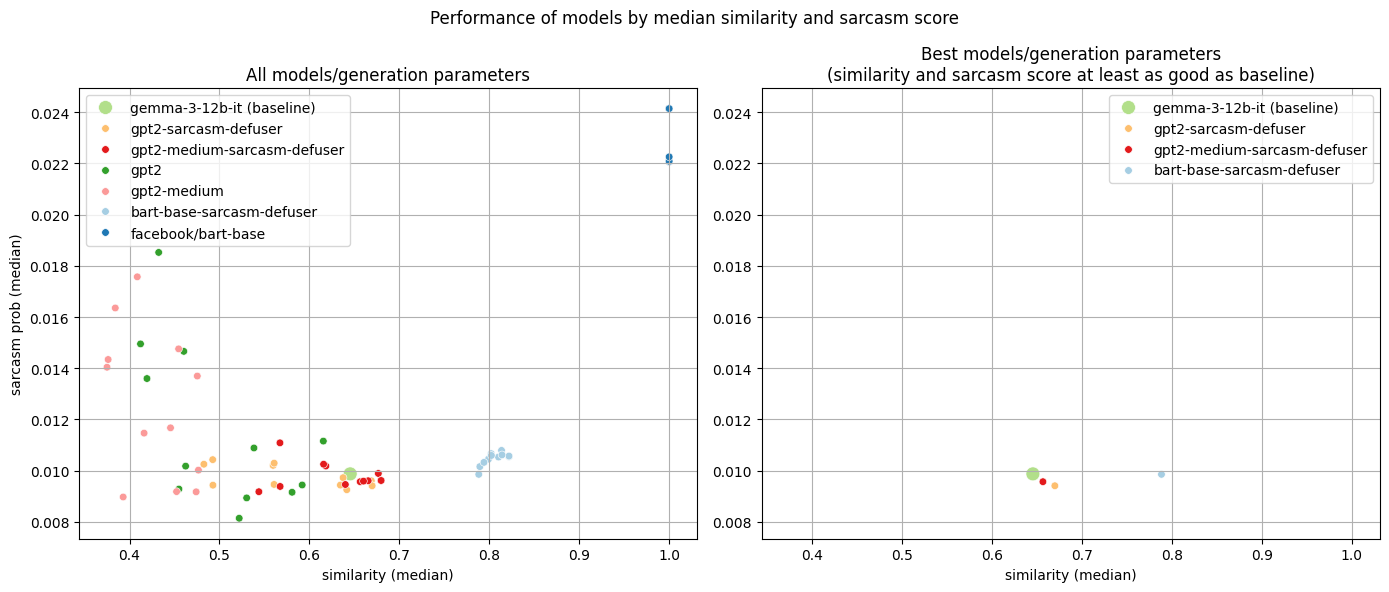

In [142]:
SIM_MOD = "multi-qa-mpnet-base-dot-v1"
SARC_MOD = "helinivan/english-sarcasm-detector"

baseline_similarity = (
    similarity_models[similarity_models.similarity_model == SIM_MOD]
    .assign(model=BASELINE_MODEL)
    .reset_index(drop=True)
)
baseline_sarcasm = (
    sarcasm_prob_neutral.loc[sarcasm_prob_neutral.sarcasm_model == SARC_MOD]
    .assign(model=BASELINE_MODEL)
    .reset_index(drop=True)
)

baseline_similarity.columns = [
    f"similarity:{c}" if c not in ["similarity_model", "model"] else c
    for c in baseline_similarity.columns
]

baseline_sarcasm.columns = [
    (
        f"sarcasm_prob_neutral:{c}"
        if c not in ["sarcasm_model", "model", "mean_ratio", "median_ratio"]
        else c
    )
    for c in baseline_sarcasm.columns
]

baseline = pd.concat(
    [
        baseline_similarity.drop(["model", "similarity_model"], axis=1).reset_index(
            drop=True
        ),
        baseline_sarcasm.reset_index(drop=True),
    ],
    axis=1,
)
baseline["label"] = f"{BASELINE_MODEL} (baseline)"

total_scores = pd.read_csv("final_project_scripts/total-scores.csv")
total_scores["label"] = total_scores["model"].str.replace("maxmarcon/", "")

best = (
    total_scores[
        (total_scores["similarity:q2"] >= baseline["similarity:q2"].item())
        & (
            total_scores["sarcasm_prob_neutral:q2"]
            <= baseline["sarcasm_prob_neutral:q2"].item()
        )
    ]
    .groupby("model")["sarcasm_prob_neutral:q2"]
    .idxmin()
)

total_scores["best"] = total_scores.index.isin(best)
total_scores["mean_ratio"] = (
    total_scores["sarcasm_prob_neutral:mean"] / total_scores["sarcasm_prob_orig:mean"]
)
total_scores["median_ratio"] = (
    total_scores["sarcasm_prob_neutral:q2"] / total_scores["sarcasm_prob_orig:q2"]
)

fig = plt.figure(figsize=(14, 6))
fig.suptitle("Performance of models by median similarity and sarcasm score")

sizes = dict.fromkeys(total_scores.label, 30)
sizes[f"{BASELINE_MODEL} (baseline)"] = 100

all_labels = (
    pd.concat([total_scores.label, baseline.label]).drop_duplicates().sort_values()
)
palette_colors = sns.color_palette('Paired', len(all_labels))
color_map = dict(zip(all_labels, palette_colors))

ax = plt.subplot(1, 2, 1)
ax.set_title("All models/generation parameters")

sns.scatterplot(
    pd.concat([baseline, total_scores]),
    x="similarity:q2",
    y="sarcasm_prob_neutral:q2",
    hue="label",
    size="label",
    palette=color_map,
    ax=ax,
    sizes=sizes,
)
ax.set_ylabel("sarcasm prob (median)")
ax.set_xlabel("similarity (median)")
xlim, ylim = ax.get_xlim(), ax.get_ylim()
ax.grid()
ax.get_legend().set_title(None)

ax = plt.subplot(1, 2, 2)
ax.set_title(
    "Best models/generation parameters\n(similarity and sarcasm score at least as good as baseline)"
)

sns.scatterplot(
    pd.concat([baseline, total_scores.loc[total_scores.best]]),
    x="similarity:q2",
    y="sarcasm_prob_neutral:q2",
    hue="label",
    palette=color_map,
    size="label",
    ax=ax,
    sizes=sizes,
)
ax.set_ylabel(None)
ax.set_xlabel("similarity (median)")
ax.grid()
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.get_legend().set_title(None)
fig.tight_layout()

The left-hand plot shows all models/configuration.

As expected, the "vanilla" `gpt2` models are unable to produce outputs that levels of similarity higher than the baseline. The sarcasm might be low, but without high similarity with the original comment this is likely to be a result of the output being a random "babbling" which is typical for these base models. The `bart` model, because it practically outputs the same sentences as the inputs (it is trained to guess missing portions of the input sentences), achieves a similarity of 1.0 and a very high median sarcasm score (i.e. the same as the original sentence)

On the other hand, some of the configurations of our trained models are able to beat the baseline (higher similarity, lower sarcasm). The best of these configurations for each of the 3 models are shown on the right-hand plot.

Finally, for the 3 winning models/configurations, we plot boxplots of similarity/sarcasm score, as well as the neutral/original ratio of the median sarcasm scores:

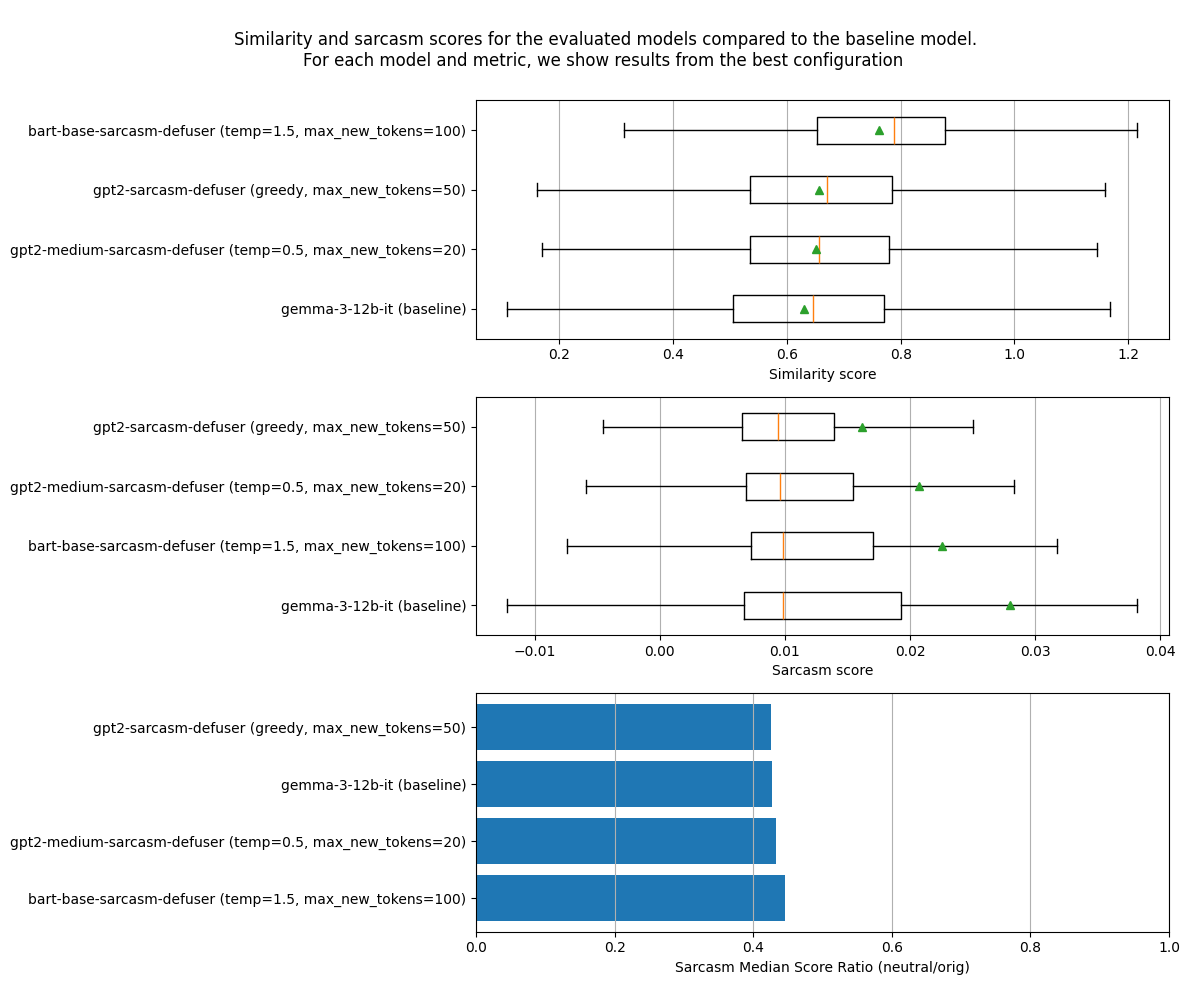

In [147]:
best_scores = total_scores.loc[total_scores.best]

similarity = best_scores[
    [
        c
        for c in total_scores.columns
        if c.startswith("similarity") or c == "model" or c.startswith("generate_params")
    ]
]
similarity = pd.concat([similarity, baseline_similarity])
similarity.columns = [c.replace("similarity:", "") for c in similarity.columns]
similarity = similarity.sort_values(by="q2")

sarcasm = best_scores[
    [
        c
        for c in total_scores.columns
        if c.startswith("sarcasm") or c == "model" or c.startswith("generate_params")
    ]
]
sarcasm.loc[:, ["median_ratio"]] = (
    sarcasm["sarcasm_prob_neutral:q2"] / sarcasm["sarcasm_prob_orig:q2"]
)
sarcasm.loc[:, ["mean_ratio"]] = (
    sarcasm["sarcasm_prob_neutral:mean"] / sarcasm["sarcasm_prob_orig:mean"]
)
sarcasm = sarcasm.drop(
    [c for c in sarcasm.columns if c.startswith("sarcasm_prob_orig")], axis=1
)

sarcasm = pd.concat([sarcasm, baseline_sarcasm])
sarcasm.columns = [c.replace("sarcasm_prob_neutral:", "") for c in sarcasm.columns]
sarcasm = sarcasm.sort_values(by="q2", ascending=False)

fig = plt.figure(figsize=(12, 10))
ax = plt.subplot(3, 1, 1)
fig.suptitle(
    """
    Similarity and sarcasm scores for the evaluated models compared to the baseline model.
    For each model and metric, we show results from the best configuration 
    """
)


labels = list(make_labels(similarity))
ax.bxp(
    list(make_bxpstats(similarity)),
    positions=range(len(labels)),
    showfliers=False,
    showmeans=True,
    orientation="horizontal",
)
ax.set_xlabel("Similarity score")
ax.grid(axis="x")
ax.set_yticks(ticks=range(len(labels)), labels=labels)
None

ax = plt.subplot(3, 1, 2)

labels = list(make_labels(sarcasm))

ax.bxp(
    list(make_bxpstats(sarcasm)),
    positions=range(len(labels)),
    showfliers=False,
    showmeans=True,
    orientation="horizontal",
)
ax.set_xlabel("Sarcasm score")
ax.grid(axis="x")
ax.set_yticks(ticks=range(len(labels)), labels=labels)

ax = plt.subplot(3, 1, 3)


sarcasm = sarcasm.sort_values(by="median_ratio", ascending=False)
labels = list(make_labels(sarcasm))

ax.barh(
    range(len(labels)),
    sarcasm["median_ratio"],
    tick_label=labels,
)
ax.set_xlim(0, 1)
ax.set_xlim(0, 1)
ax.grid(axis="x")
ax.set_xlabel("Sarcasm Median Score Ratio (neutral/orig)")


# ax.legend()

fig.tight_layout()

None

All these 3 models achieve a very high reduction in sarcasm. However, `bart-base-sarcasm-defuser` stands out because it also achieves a very high similarity score, even though the sarcasm is a bit lower than the other 2 models.

It's interesting to note that there's no considerable improvement between `gpt2-sarcasm-defuser` with 0.1B parameter to `gpt2-medium-sarcasm-defuser` with 0.4B parameters.



## Resources

The trained models are available on Huggingface:

* **[maxmarcon/gpt2-sarcasm-defuser](https://huggingface.co/maxmarcon/gpt2-sarcasm-defuser)**
* **[maxmarcon/gpt2-medium-sarcasm-defuser](https://huggingface.co/maxmarcon/gpt2-medium-sarcasm-defuser)**
* **[maxmarcon/bart-base-sarcasm-defuser](https://huggingface.co/maxmarcon/bart-base-sarcasm-defuser)**

And they can be tested on [this web application](https://huggingface.co/spaces/maxmarcon/sarcasm-defuser).

The code used to train and evaluate the models is [available here](https://github.com/maxmarcon/sarcasm-defuser/). 

## Limitations and ideas for future work


These are relative simple models trained on a relatively small dataset. We see the following areas for improvement:

1. Increase the size of the training set by producing more sarcastic comments and their neutral version. In order to do so, we should even use more sophisticated models than `gemma` (that will come at higher cost of course)
2. Use better methods to measure sarcasm and similarity. Especially the sarcasm score of the original comments is not very high to begin with, which suggests that the available models we used to measure sarcasm level aren't very good or need to be fine-tuned. More research on how to proper measure sarcasm would make the evaluation of our sarcasm defusing models more precise and give us more confidence in the results
3. The sarcasm defuser works in some cases, but fails in many others. For example, the sarcastic comment: `Oh that's great, thank you very much!`
gets translated into: `That's great, I appreciate you sharing that`. It's clear that the above comment, when expressed sarcastically, means exactly the opposite of what it's saying, namely that the speaker isn't happy at all with the current situation. Our current defuser is only occasionally able to deal with this kind of comments and typically misses the nuance in the sarcastic comment. In order to improve on this, we could introduce a "meaning reversal" metric and measure if the meaning of the original comment has been "reversed" in the translated one. So to evaluate the translated comment we would use the following criteria:
    1. **Sarcasm score:** has to be lower than the original comment's
    2. **Similarity score:** has to be high between original and sarcastic comment
    3. **Meaning:** has to be reversed from the original comment's
4. Add context. Context is important to sarcasm and in fact we used the context (i.e. the comment preceding the sarcastic one) as input to `gemma` in order to produce neutral comments. For sake of simplicity, we didn't use the context when training our models. Adding the context might considerably increase the performance of our models and maybe even solve some of the problems outlined at point (3) above

